In [12]:
%load_ext autoreload
%autoreload 2
DATA_SEED = 613
MODEL_SEED = 26
LANGEVIN_SEED = 480

import re
from pathlib import Path

import juliacall
import os
import torch
import numpy as np
from dataclasses import dataclass, field
import sys
import scipy.stats as stats
from juliacall import Main as jl
jl.include('/home/akiva/FCNX-Ensembling/julia_lib/FCS.jl')
sys.path.insert(0, '/home/akiva/FCNX-Ensembling/lib')
torch.manual_seed(DATA_SEED)
torch.set_default_dtype(torch.float64)
DEVICE = torch.device('cuda:1')

from FCN3Network import FCN3NetworkEnsembleErf
from Experiment import Experiment, ExperimentLinear

import torch
import matplotlib.pyplot as plt
from opt_einsum import contract
from scipy.sparse.linalg import eigsh  # Lanczos method for symmetric matrices


experiments = [
    Experiment(
        eps=0.03,
        file = '/home/akiva/exp/fcn3erf/erf_cubic_P_1600_D_40_N_256_epochs_40000000_lrA_6.25e-11_time_20251030_174053',
        N=256,
        d=40,
        chi=25,
        P=1600,
        ens=10,
        device = torch.device('cuda:1')
    ),Experiment(
        eps = 0.03, 
        file = '/home/akiva/exp/fcn3erf/erf_cubic_P_30_D_25_N_250_epochs_40000000_lrA_1.11e-08_time_20251030_121338',
        N=250,
        d=25,
        ens=5,
        chi=1.0,
        P=30
    ),Experiment(
        eps=0.00,
        file = '/home/akiva/exp/fcn3erf/erf_P_30_D_25_N_250_epochs_250000000_lrA_1.11e-07_time_20250922_144935',
        N=250,
        d=25,
        chi=250,
        P=30,
        ens=7,
    ), Experiment(
        file = '/home/akiva/exp/fcn3erf/erf_cubic_P_130_D_25_N_250_epochs_300000000_lrA_7.69e-09_time_20251030_175255',
        P = 130,
        d=25,
        N=250,
        chi=25,
        ens=25,
        eps=0.00
    ), Experiment(
        file = '/home/akiva/exp/fcn3erf/erf_cubic_P_1875_D_25_N_400_epochs_2000000_lrA_1.78e-09_time_20251112_161015',
        P = 1875,
        d=25,
        N=400,
        chi=100,
        eps=0.4,
        ens=5
    ), Experiment(
        d=25,
        P=30,
        N=250,
        ens = 7, 
        eps = 0.4,
        chi=250,
        file = '/home/akiva/exp/fcn3erf/erf_cubic_P_30_D_25_N_250_epochs_25000000_lrA_1.11e-07_time_20251113_122128'
    ), Experiment(
        file='/home/akiva/exp/fcn3erf/erf_cubic_P_2500_D_50_N_400_epochs_30000000_lrA_1.33e-07_time_20251113_151231/',
        device=torch.device('cuda:1'),
        P=2500,
        d=50,
        N=400,
        chi=100,
        eps=4.0,
        ens=8
    ), Experiment(
        file = '/home/akiva/exp/fcn3erf/erf_cubic_P_300_D_20_N_200_epochs_30000000_lrA_1.11e-06_time_20251116_110854/',
        device=torch.device('cuda:1'),
        P = 300,
        d=20,
        N=200,
        chi=200,
        eps=4.0,
        ens = 5
    ), Experiment(
        file='/home/akiva/exp/fcn3erf/erf_cubic_P_250_D_20_N_120_epochs_30000000_lrA_1.33e-07_time_20251116_210435',
        device=torch.device('cuda:1'),
        P=250,
        d=20,
        N=120,
        chi=60,
        eps=0.4,
        ens=10
    ), Experiment(
    file='/home/akiva/exp/fcn3erf/erf_cubic_eps_0.3_P_2500_D_40_N_400_epochs_25000000_lrA_1.33e-07_time_20251117_132840/',
    P = 1000,
    d=40,
    N=400,
    chi=100,
    eps=0.3,
    ens=3,
    device=torch.device('cuda:1')),
    Experiment(
        file = '/home/akiva/exp/fcn3erf/erf_cubic_P_300_D_20_N_200_epochs_30000000_lrA_1.11e-06_time_20251116_110854/',
        device=torch.device('cuda:1'),
        P = 300,
        d=20,
        N=200,
        chi=200,
        eps=4.0,
        ens = 5
    ),
    Experiment(
    eps=0.03,
    file='/home/akiva/exp/fcn3erf/erf_cubic_eps_0.3_P_2500_D_40_N_400_epochs_25000000_lrA_1.33e-07_time_20251117_132840',
    N=400,
    chi=400,
    P=2500,
    ens=10,
    d=40
)
]

exp_root = '/home/akiva/exp/fcn3erf/'
folders = sorted(
    [os.path.join(exp_root, name) for name in os.listdir(exp_root)
     if os.path.isdir(os.path.join(exp_root, name))]
)
folders = [f for f in folders if "N_400" in os.path.basename(f)]
# check if model.pth exists in f

folders = [f for f in folders if os.path.exists(os.path.join(f, "model.pth"))]

PARAM_RE = re.compile(r"([a-zA-Z]+)_(-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?(?:_\d+)?)")

def _cast(value):
    if "_" in value:
        return value          # timestamp, e.g. 20251117_132840 — leave as string
    if re.fullmatch(r"-?\d+", value):
        return int(value)
    return float(value)

def experiment_from_filename(f, ens=10, chi=400):
    name = Path(f).stem
    params = {key: _cast(val) for key, val in PARAM_RE.findall(name)}

    return Experiment(
        eps=params["eps"] if hasattr(params, "eps") else 0.03,
        file=f,
        N=int(params["N"]),
        chi=int(params["N"]),
        P=int(params["P"]),
        ens=ens,
        d=int(params["D"]),
    )

experiments = [experiment_from_filename(f) for f in folders]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:

def log_density_of_projections(h,y):

    hs = torch.einsum('uji,uk->jik', h, y) / (y.shape[0])
    heTs = hs.flatten(start_dim=0, end_dim=1)[:,0].detach().cpu().numpy()
    hePs = hs.flatten(start_dim=0, end_dim=1)[:,1:].detach().cpu().numpy().flatten()

    countsT, bin_edgesT = np.histogram(heTs, bins=25,density= True)
    countsP, bin_edgesP = np.histogram(hePs, bins=25,density= True)

    # Bin width
    bw = lambda be: be[1] - be[0]
    bc = lambda be: 0.5 * (be[:-1] + be[1:])
    # Compute log density
    log_density_T = -np.log(countsT) #* bw(bin_edgesT))  # add epsilon to avoid log(0)
    log_density_P = -np.log(countsP)#* bw(bin_edgesP))  # add epsilon to avoid log(0)
    return bc(bin_edgesT), log_density_T, bc(bin_edgesP), log_density_P


In [3]:
norm(4)

NameError: name 'norm' is not defined

Reinitializing model: loaded ensemble size 20 != preinitialized ens 10
Loaded model state_dict from /home/akiva/exp/fcn3erf/erf_P_20_D_20_N_400_epochs_10000000_lrA_5.00e-10_time_20250805_135205/model.pth
torch.Size([10000, 20, 400]) torch.Size([10000, 20])
Reinitializing model: loaded ensemble size 20 != preinitialized ens 10


/tmp/ipykernel_230952/3903088068.py:14: RuntimeWarning: divide by zero encountered in log
  log_density_T = -np.log(countsT) #* bw(bin_edgesT))  # add epsilon to avoid log(0)


Loaded model state_dict from /home/akiva/exp/fcn3erf/erf_P_20_D_20_N_400_epochs_10000000_lrA_5.00e-10_time_20250805_135231/model.pth
torch.Size([10000, 20, 400]) torch.Size([10000, 20])
Loaded model state_dict from /home/akiva/exp/fcn3erf/erf_P_20_D_20_N_400_epochs_20000000_lrA_5.00e-10_time_20250806_185503/model.pth
torch.Size([10000, 10, 400]) torch.Size([10000, 20])
Reinitializing model: loaded ensemble size 50 != preinitialized ens 10


/tmp/ipykernel_230952/3903088068.py:15: RuntimeWarning: divide by zero encountered in log
  log_density_P = -np.log(countsP)#* bw(bin_edgesP))  # add epsilon to avoid log(0)
/tmp/ipykernel_230952/2146978291.py:48: RuntimeWarning: divide by zero encountered in log
  ldT = -np.log(ctT) #* bw(bneT))


Loaded model state_dict from /home/akiva/exp/fcn3erf/erf_P_30_D_20_N_400_epochs_50000000_lrA_3.33e-08_time_20250902_113600/model.pth
torch.Size([10000, 50, 400]) torch.Size([10000, 20])
Reinitializing model: loaded ensemble size 50 != preinitialized ens 10
Loaded model state_dict from /home/akiva/exp/fcn3erf/erf_P_30_D_20_N_400_epochs_50000000_lrA_3.33e-10_time_20250902_164258/model.pth
torch.Size([10000, 50, 400]) torch.Size([10000, 20])
Reinitializing model: loaded ensemble size 50 != preinitialized ens 10
Loaded model state_dict from /home/akiva/exp/fcn3erf/erf_P_30_D_20_N_400_epochs_8000000_lrA_3.33e-08_time_20250901_194036/model.pth
torch.Size([10000, 50, 400]) torch.Size([10000, 20])
Reinitializing model: loaded ensemble size 50 != preinitialized ens 10
Loaded model state_dict from /home/akiva/exp/fcn3erf/erf_P_30_D_20_N_400_epochs_8000000_lrA_3.33e-08_time_20250901_194119/model.pth
torch.Size([10000, 50, 400]) torch.Size([10000, 20])
Reinitializing model: loaded ensemble size 8 

/tmp/ipykernel_230952/2146978291.py:49: RuntimeWarning: divide by zero encountered in log
  ldP = -np.log(ctP) # * bw(bneP))
/tmp/ipykernel_230952/2146978291.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend()


Reinitializing model: loaded ensemble size 3 != preinitialized ens 10
Loaded model state_dict from /home/akiva/exp/fcn3erf/erf_cubic_eps_0.03_P_250_D_40_N_400_epochs_25000000_lrA_1.33e-06_time_20251118_155401/model.pth
torch.Size([10000, 3, 400]) torch.Size([10000, 40])
Reinitializing model: loaded ensemble size 3 != preinitialized ens 10
Loaded model state_dict from /home/akiva/exp/fcn3erf/erf_cubic_eps_0.3_P_2500_D_40_N_400_epochs_25000000_lrA_1.33e-07_time_20251117_132840/model.pth
torch.Size([10000, 3, 400]) torch.Size([10000, 40])


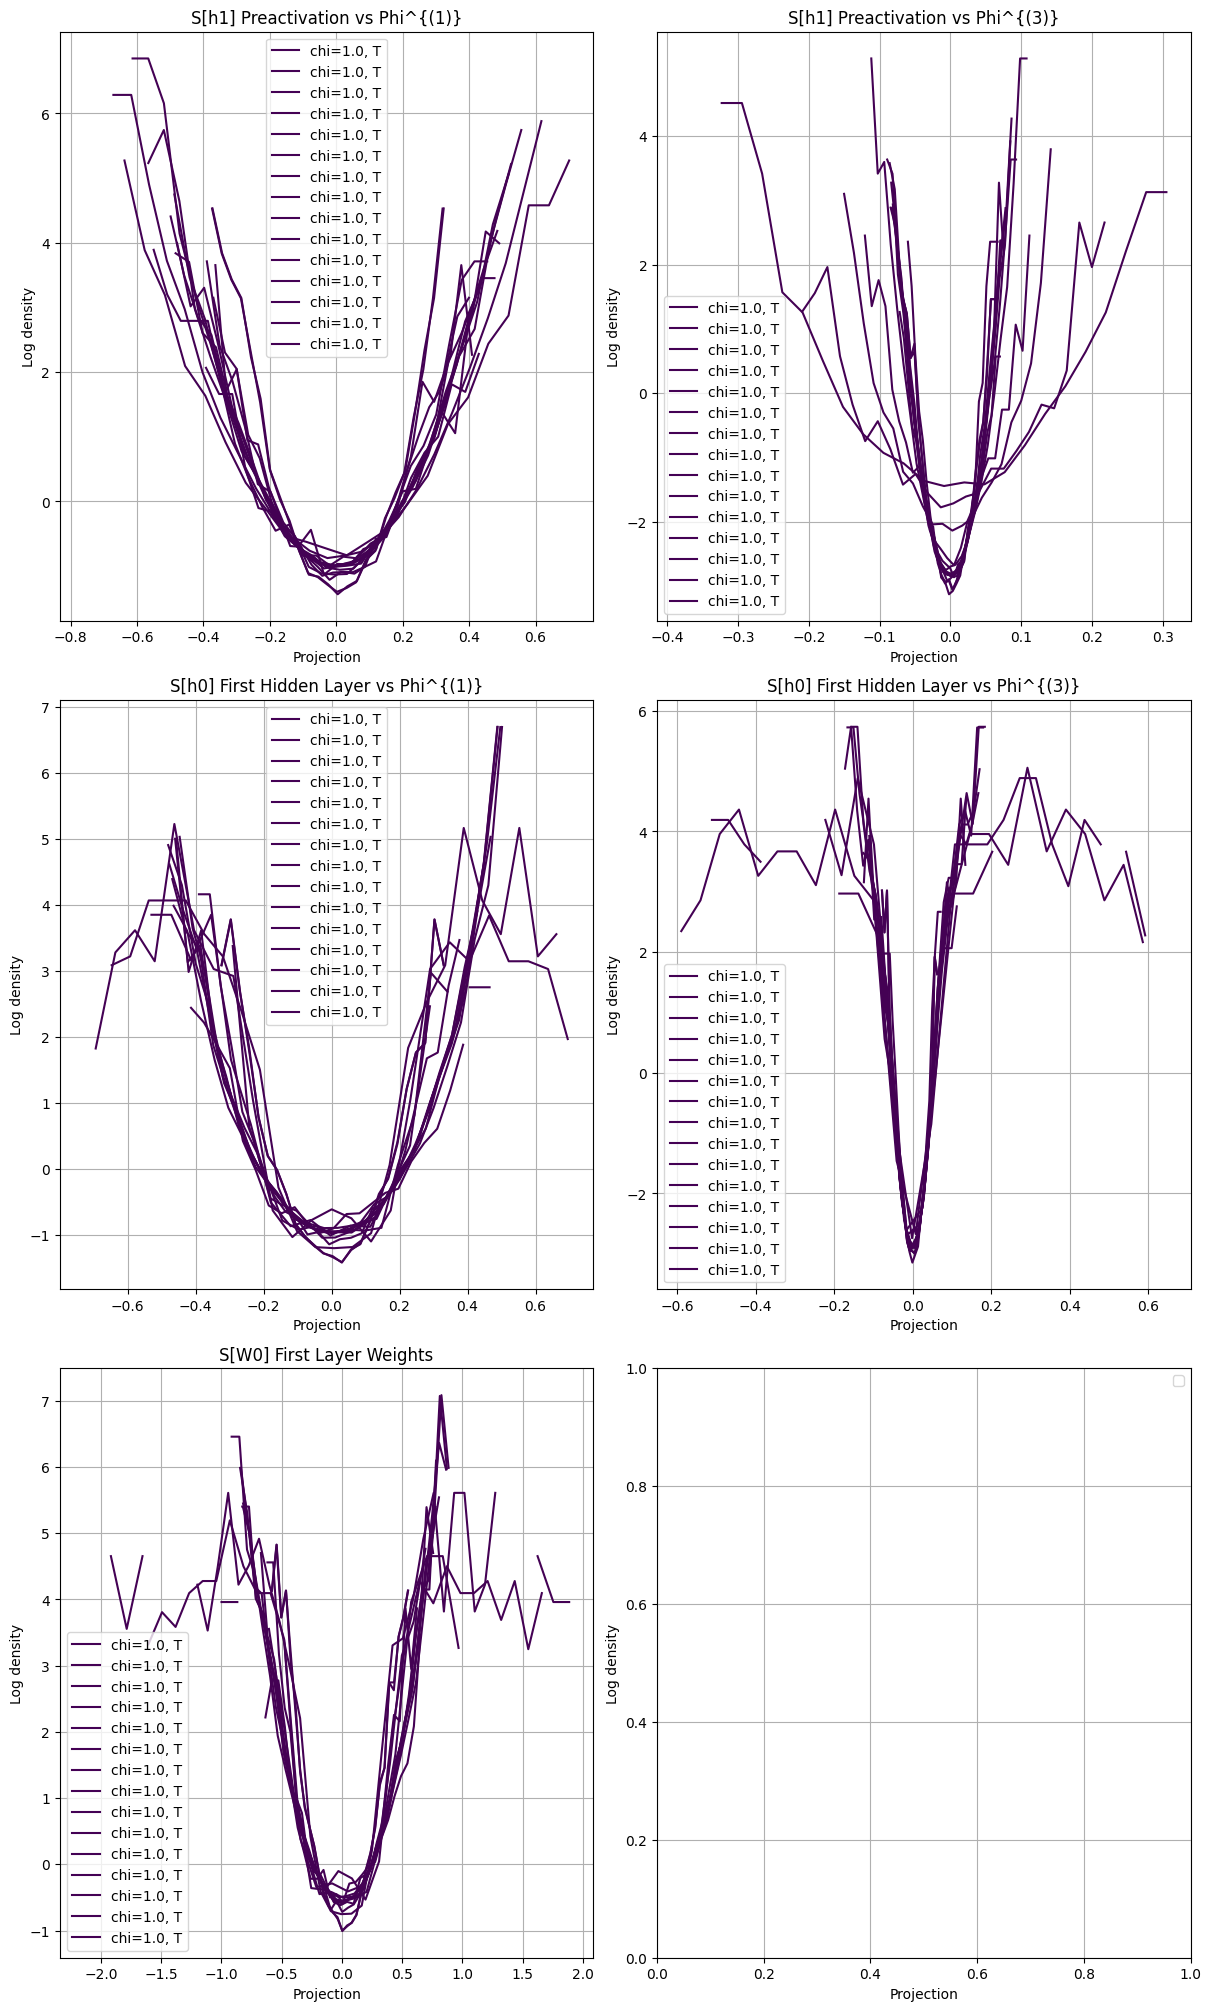

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Define line styles
line_styles = {'T': '-', 'P': '--'}

# Normalize epsilon values for colormap
chi_values = [exp.chi / exp.N if hasattr(exp, 'chi') else 0.0 for exp in experiments]
norm = plt.Normalize(min(chi_values), max(chi_values))
cmap = cm.viridis

# Precompute X and model from first experiment (assuming all experiments use same input space)

fig, ax = plt.subplots(3, 2, figsize=(12, 20), layout='constrained')

for experiment in experiments:
    experiment.load()
    model = experiment.model
    model.to(torch.device('cuda:1'))
    # Compute preactivations
    X, _ = experiment.large_dataset(p_large=10000)
    Y1 = X
    Y3 = X**3 - 3 * X
    Y = Y1 + experiment.eps * Y3
    h1 = model.h1_preactivation(X)
    h0 = torch.erf(torch.einsum('qkl,ul->uqk', model.W0, X))
    print(h1.shape, Y.shape)
    # Compute log densities for Y1 and Y3
    for Y, row_label in zip([Y1, Y3], ['1','2']):
        bcT, ldT, bcP, ldP = log_density_of_projections(h1, Y)
        ax_idx = (0, int(row_label)-1)
        ax[0, int(row_label)-1].plot(bcT, ldT, color=cmap(norm(experiment.chi / experiment.N)), linestyle=line_styles['T'], label=f'chi={experiment.chi / experiment.N}, T')
        # ax[0, int(row_label)-1].plot(bcP, ldP, color=cmap(norm(experiment.chi)), linestyle=line_styles['P'], label=f'chi={experiment.chi / experiment.N}, P')
        
        # First hidden layer
        bcT0, ldT0, bcP0, ldP0 = log_density_of_projections(h0, Y)
        ax[1, int(row_label)-1].plot(bcT0, ldT0, color=cmap(norm(experiment.chi / experiment.N)), linestyle=line_styles['T'], label=f'chi={experiment.chi / experiment.N}, T')
        # ax[1, int(row_label)-1].plot(bcP0, ldP0, color=cmap(norm(experiment.chi)), linestyle=line_styles['P'], label=f'chi={experiment.chi / experiment.N}, P')

    # First layer weights
    w0T = model.W0[:,:,0].detach().cpu().numpy()
    w0P = model.W0[:,:,1:].detach().cpu().numpy()
    ctT, bneT = np.histogram(w0T, bins=30,density=True)
    ctP, bneP = np.histogram(w0P, bins=30,density=True)
    bw = lambda be: be[1]-be[0]
    bc = lambda be: 0.5*(be[:-1]+be[1:])
    ldT = -np.log(ctT) #* bw(bneT))
    ldP = -np.log(ctP) # * bw(bneP))
    ax[2,0].plot(bc(bneT), ldT, color=cmap(norm(experiment.chi / experiment.N)), linestyle=line_styles['T'], label=f'chi={experiment.chi / experiment.N}, T')
    # ax[2,0].plot(bc(bneP), ldP, color=cmap(norm(experiment.chi)), linestyle=line_styles['P'], label=f'chi={experiment.chi / experiment.N}, P')

# Titles and labels
ax[0,0].set_title("S[h1] Preactivation vs Phi^{(1)}")
ax[0,1].set_title("S[h1] Preactivation vs Phi^{(3)}")
ax[1,0].set_title("S[h0] First Hidden Layer vs Phi^{(1)}")
ax[1,1].set_title("S[h0] First Hidden Layer vs Phi^{(3)}")
ax[2,0].set_title("S[W0] First Layer Weights")
for axs in ax.flatten():
    axs.set_xlabel("Projection")
    axs.set_ylabel("Log density")
    axs.grid(True)
    # Optional: Only show legend in first row to avoid clutter
    axs.legend()

plt.show()
